<a href="https://colab.research.google.com/github/alfarisauliarahman/BigData26_A_2411533006_AlfarisAuliaRahman/blob/main/Praktikum01/BD_A_T01_2411533006_AlfarisAuliaRahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum Big Data - Praktikum 1
**Nama:** Alfaris Aulia Rahman  
**NIM:** 2411533006  
**Kelas:** A


## 1. Verifikasi lingkungan dan persiapan penyimpanan

In [20]:
import os
import sys
import gc
import time
import shutil
import subprocess
import platform
import multiprocessing

import numpy as np
import pandas as pd
import psutil
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())
for nama in ["pandas", "numpy", "pyarrow", "matplotlib", "psutil"]:
    modul = __import__(nama)
    print(f"{nama:11s}:", getattr(modul, "__version__", "tersedia"))
print("Java:")
try:
    subprocess.run(["java", "-version"], check=False)
except FileNotFoundError:
    print("Java belum terpasang; Spark akan gagal dijalankan.")

mem = psutil.virtual_memory()
print(f"RAM total: {mem.total / 1024**3:.1f} GB | tersedia: {mem.available / 1024**3:.1f} GB")
disk = shutil.disk_usage(os.getcwd())
print(f"Disk kosong: {disk.free / 1024**3:.1f} GB")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
psutil     : 5.9.5
Java:
RAM total: 12.7 GB | tersedia: 3.9 GB
Disk kosong: 87.0 GB


## 2. Menghubungkan Drive dan menyiapkan dataset

In [4]:
from google.colab import drive
drive.mount("/content/drive")

DIR_DATA = "/content/drive/MyDrive/BigData/Praktikum1"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Tugas01"
os.makedirs(DIR_SIMPAN, exist_ok=True)

PATH_JAN = os.path.join(DIR_DATA, "yellow_tripdata_2023-01.parquet")
PATH_JUL = os.path.join(DIR_DATA, "yellow_tripdata_2023-07.parquet")
file_wajib = [PATH_JAN, PATH_JUL]
file_hilang = [p for p in file_wajib if not os.path.isfile(p)]
if file_hilang:
    raise FileNotFoundError(
        "Dataset tidak ditemukan di Google Drive: " + ", ".join(file_hilang)
    )

print("DIR_DATA  :", DIR_DATA)
print("DIR_SIMPAN:", DIR_SIMPAN)
for path in file_wajib:
    print(os.path.basename(path), "|", round(os.path.getsize(path) / 1024**2, 1), "MB")

Mounted at /content/drive
DIR_DATA  : /content/drive/MyDrive/BigData/Praktikum1
DIR_SIMPAN: /content/drive/MyDrive/BigData/Tugas01
yellow_tripdata_2023-01.parquet | 45.5 MB
yellow_tripdata_2023-07.parquet | 46.1 MB


## 3. Alat ukur waktu dan memori

RSS dipakai sebagai indikator pertumbuhan memori proses. Angka RSS bersifat indikatif karena dipengaruhi garbage collector dan buffer pembaca file.

In [5]:
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta, 1)
    })
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

## 4. J-4: inspeksi metadata dataset Juli 2023

Metadata Parquet dibaca tanpa memuat seluruh baris ke memori.

In [6]:
meta_juli = pq.ParquetFile(PATH_JUL).metadata
parquet_juli = pq.ParquetFile(PATH_JUL)
print("Ukuran file :", round(os.path.getsize(PATH_JUL) / 1024**2, 1), "MB")
print("Jumlah baris:", f"{meta_juli.num_rows:,}")
print("Jumlah kolom:", meta_juli.num_columns)
print("Row group  :", meta_juli.num_row_groups)
print("Kolom      :", parquet_juli.schema.names)

Ukuran file : 46.1 MB
Jumlah baris: 2,907,108
Jumlah kolom: 19
Row group  : 1
Kolom      : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


## 5. J-5: membaca data dan mengoptimalkan memori

Percobaan pertama membaca semua kolom, lalu percobaan kedua hanya membaca kolom yang diperlukan untuk analisis.

In [7]:
KOLOM = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "payment_type",
    "fare_amount", "tip_amount", "total_amount"
]

penuh_juli = ukur("baca semua kolom Juli", lambda: pd.read_parquet(PATH_JUL))
print("Dimensi semua kolom:", penuh_juli.shape)
print("Memori semua kolom:", round(penuh_juli.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
del penuh_juli

gc.collect()
df_juli = ukur("baca kolom terpilih Juli", lambda: pd.read_parquet(PATH_JUL, columns=KOLOM))
print("Dimensi kolom terpilih:", df_juli.shape)
print("Memori kolom terpilih:", round(df_juli.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
display(df_juli.head())

[baca semua kolom Juli] 4.50 s | RSS +495.5 MB
Dimensi semua kolom: (2907108, 19)
Memori semua kolom: 502.5 MB
[baca kolom terpilih Juli] 0.69 s | RSS +121.1 MB
Dimensi kolom terpilih: (2907108, 8)
Memori kolom terpilih: 177.4 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-07-01 00:29:59,2023-07-01 00:40:15,1.0,1.80,1,12.1,5.10,22.20
1,2023-07-01 00:03:25,2023-07-01 00:23:44,1.0,2.31,2,19.1,0.00,24.10
2,2023-07-01 00:38:29,2023-07-01 00:48:53,1.0,2.36,1,13.5,3.70,22.20
3,2023-07-01 00:14:16,2023-07-01 00:29:13,1.0,4.36,1,19.8,4.96,29.76
4,2023-07-01 00:11:15,2023-07-01 00:20:47,0.0,1.60,1,11.4,3.25,19.65


In [8]:
sebelum_juli = df_juli.memory_usage(deep=True).sum() / 1024**2

df_juli["passenger_count"] = pd.to_numeric(df_juli["passenger_count"], downcast="float")
df_juli["payment_type"] = df_juli["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df_juli[kol] = pd.to_numeric(df_juli[kol], downcast="float")

sesudah_juli = df_juli.memory_usage(deep=True).sum() / 1024**2
print(f"Optimasi tipe: {sebelum_juli:.1f} MB -> {sesudah_juli:.1f} MB "
      f"(hemat {100 * (1 - sesudah_juli / sebelum_juli):.1f}%)")
display(df_juli.dtypes)

Optimasi tipe: 177.4 MB -> 113.7 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


## 6. J-6: pemeriksaan kualitas dan pembersihan data Juli

Threshold pembersihan dipertahankan agar perbandingan Januari dan Juli menggunakan definisi data bersih yang sama.

In [9]:
df_juli["durasi_menit"] = (
    df_juli["tpep_dropoff_datetime"] - df_juli["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print(df_juli[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:")
print(df_juli.isna().sum())

anomali_juli = {
    "jarak <= 0": (df_juli["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df_juli["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df_juli["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df_juli["total_amount"] <= 0).sum()
}
for k, v in anomali_juli.items():
    print(f"{k:22s}: {v:,} baris ({100 * v / len(df_juli):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   2.907108e+06  2.907108e+06  2.907108e+06
mean    4.489381e+00  1.707664e+01  2.856786e+01
std     2.578832e+02  4.099461e+01  2.446845e+01
min     0.000000e+00 -5.711667e+01 -6.223000e+02
25%     1.060000e+00  7.466667e+00  1.570000e+01
50%     1.810000e+00  1.240000e+01  2.090000e+01
75%     3.580000e+00  2.033333e+01  3.080000e+01
max     1.919450e+05  7.348833e+03  1.079450e+03

Nilai kosong per kolom:
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          85086
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 49,790 baris (1.71%)
durasi <= 0           : 1,395 baris (0.05%)
durasi > 180 menit    : 2,760 baris (0.09%)
total_amount <= 0     : 31,240 baris (1.07%)


In [10]:
layak_juli = (
    (df_juli["trip_distance"] > 0) & (df_juli["trip_distance"] < 100) &
    df_juli["durasi_menit"].between(1, 180) &
    (df_juli["total_amount"] > 0)
)
bersih_juli = df_juli.loc[layak_juli].copy()
print(f"{len(df_juli):,} baris -> {len(bersih_juli):,} baris "
      f"(dibuang {len(df_juli) - len(bersih_juli):,}; "
      f"{100 * (len(df_juli) - len(bersih_juli)) / len(df_juli):.2f}%)")

2,907,108 baris -> 2,817,657 baris (dibuang 89,451; 3.08%)


## 7. J-7: chunking pada data Juli

Data bersih ditulis ke CSV yang lebih besar, lalu diagregasi per potongan tanpa memuat CSV lengkap sekaligus.

In [11]:
CSV_JULI = os.path.join(DIR_SIMPAN, "trips_juli_bersih.csv")
ukur("tulis CSV Juli", lambda: bersih_juli.to_csv(CSV_JULI, index=False))
print("Parquet Juli:", round(os.path.getsize(PATH_JUL) / 1024**2, 1), "MB")
print("CSV bersih  :", round(os.path.getsize(CSV_JULI) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris_juli, total_juli, per_jam_chunk_juli = ukur(
    "agregasi chunking Juli", lambda: agregasi_bertahap(CSV_JULI)
)
print(f"{baris_juli:,} baris | rata-rata total_amount = {total_juli / baris_juli:.2f}")

[tulis CSV Juli] 42.82 s | RSS +5.6 MB
Parquet Juli: 46.1 MB
CSV bersih  : 213.6 MB
[agregasi chunking Juli] 5.03 s | RSS +29.3 MB
2,817,657 baris | rata-rata total_amount = 29.04


## 8. J-8: PySpark local mode untuk Juli

Spark dijalankan pada satu mesin menggunakan `local[*]`, sesuai pendekatan pada modul.

In [12]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-A-T01-Juli")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

sdf_juli = spark.read.parquet(PATH_JUL)
sdf_juli.printSchema()
print("Jumlah baris:", ukur("spark count Juli", lambda: sdf_juli.count()))

sdf_bersih_juli = (sdf_juli
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime") -
         F.unix_timestamp("tpep_pickup_datetime")) / 60
    )
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
)

hasil_spark_juli = (sdf_bersih_juli
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(
        F.count("*").alias("jumlah"),
        F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
        F.round(F.avg("total_amount"), 2).alias("rata_tarif")
    )
    .orderBy("jam"))

ukur("Spark agregasi Juli", lambda: hasil_spark_juli.show(24, truncate=False))
sdf_bersih_juli.createOrReplaceTempView("trips_juli_bersih")
print("Agregasi payment_type:")
spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips_juli_bersih
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()
print("Rencana eksekusi agregasi per jam:")
hasil_spark_juli.explain()
spark.stop()

Spark: 4.0.4
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count Juli] 2.86 s | RSS +0.0 MB
Jumlah baris: 2907108
+---+------+----------+----------+
|jam|jumlah|rat

## 9. J-9: agregasi akhir dan penyimpanan artefak Juli

Artefak utama tugas disimpan ke `DIR_SIMPAN` agar tidak hilang ketika runtime Colab berakhir.

In [13]:
bersih_juli["jam"] = bersih_juli["tpep_pickup_datetime"].dt.hour
agregasi_juli = (bersih_juli
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index())

PATH_AGREGASI_JULI_CSV = os.path.join(DIR_SIMPAN, "agregasi_per_jam.csv")
PATH_AGREGASI_JULI_PARQUET = os.path.join(DIR_SIMPAN, "agregasi_per_jam.parquet")
PATH_BERSIH_JULI = os.path.join(DIR_SIMPAN, "bersih_juli.parquet")
PATH_KINERJA = os.path.join(DIR_SIMPAN, "pengukuran_kinerja.csv")

agregasi_juli.to_csv(PATH_AGREGASI_JULI_CSV, index=False)
agregasi_juli.to_parquet(PATH_AGREGASI_JULI_PARQUET, index=False)
bersih_juli.to_parquet(PATH_BERSIH_JULI, index=False)
pd.DataFrame(catatan).to_csv(PATH_KINERJA, index=False)

print("Artefak tersimpan:")
for p in [PATH_AGREGASI_JULI_CSV, PATH_AGREGASI_JULI_PARQUET, PATH_BERSIH_JULI, PATH_KINERJA]:
    print(os.path.basename(p), round(os.path.getsize(p) / 1024**2, 2), "MB")
display(agregasi_juli)

Artefak tersimpan:
agregasi_per_jam.csv 0.0 MB
agregasi_per_jam.parquet 0.0 MB
bersih_juli.parquet 50.78 MB
pengukuran_kinerja.csv 0.0 MB


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


## 10. J-10: visualisasi agregasi Juli

Satu grafik digunakan untuk menyampaikan pola permintaan per jam.

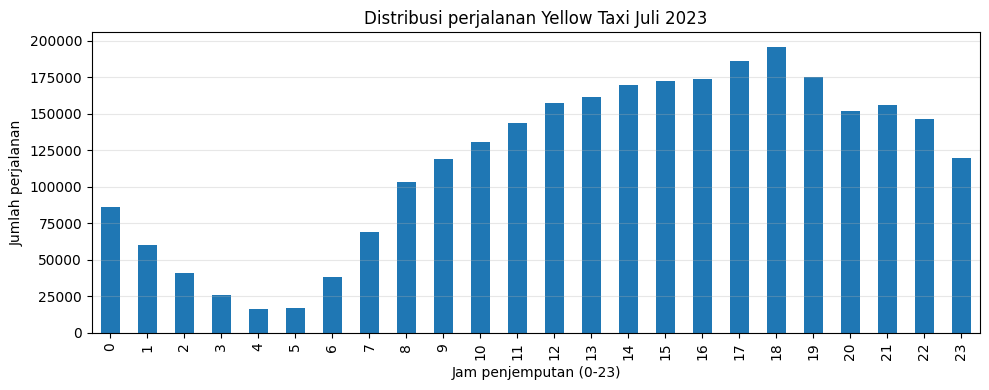

In [14]:
ax = agregasi_juli.plot(
    x="jam", y="jumlah_perjalanan", kind="bar",
    figsize=(10, 4), legend=False
)
ax.set_title("Distribusi perjalanan Yellow Taxi Juli 2023")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_xticks(range(24))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
PATH_GRAFIK_JULI = os.path.join(DIR_SIMPAN, "distribusi_per_jam_juli.png")
plt.savefig(PATH_GRAFIK_JULI, dpi=150, bbox_inches="tight")
plt.show()

## Tugas 2: perbandingan pola Januari dan Juli

Perbandingan memakai definisi pembersihan yang sama. Tabel menunjukkan jumlah perjalanan bersih per jam dan perubahan Juli terhadap Januari.

In [15]:
def ringkasan_bulanan(path, label):
    data = pd.read_parquet(path, columns=KOLOM)
    data["durasi_menit"] = (
        data["tpep_dropoff_datetime"] - data["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60
    layak = (
        (data["trip_distance"] > 0) & (data["trip_distance"] < 100) &
        data["durasi_menit"].between(1, 180) &
        (data["total_amount"] > 0)
    )
    bersih = data.loc[layak].copy()
    bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour
    hasil = (bersih.groupby("jam")
        .agg(
            jumlah_perjalanan=("total_amount", "size"),
            rata_durasi=("durasi_menit", "mean"),
            rata_tarif=("total_amount", "mean")
        )
        .round(2)
        .reset_index())
    hasil["bulan"] = label
    return hasil, len(data), len(bersih)

ringkas_jan, baris_jan, bersih_jan = ringkasan_bulanan(PATH_JAN, "Januari 2023")
ringkas_jul, baris_jul, bersih_jul = ringkasan_bulanan(PATH_JUL, "Juli 2023")

perbandingan_bulan = (ringkas_jan[["jam", "jumlah_perjalanan"]]
    .rename(columns={"jumlah_perjalanan": "jumlah_januari"})
    .merge(
        ringkas_jul[["jam", "jumlah_perjalanan"]]
        .rename(columns={"jumlah_perjalanan": "jumlah_juli"}),
        on="jam", how="outer"
    )
    .fillna(0)
    .sort_values("jam"))
perbandingan_bulan["perubahan_persen_juli_vs_jan"] = np.where(
    perbandingan_bulan["jumlah_januari"] > 0,
    100 * (perbandingan_bulan["jumlah_juli"] - perbandingan_bulan["jumlah_januari"]) /
    perbandingan_bulan["jumlah_januari"],
    np.nan
).round(2)

print(f"Januari: {baris_jan:,} baris mentah -> {bersih_jan:,} bersih")
print(f"Juli   : {baris_jul:,} baris mentah -> {bersih_jul:,} bersih")
display(perbandingan_bulan)

Januari: 3,066,766 baris mentah -> 2,986,911 bersih
Juli   : 2,907,108 baris mentah -> 2,817,657 bersih


,jam,jumlah_januari,jumlah_juli,perubahan_persen_juli_vs_jan
0,0,82289,85987,4.49
1,1,57766,59980,3.83
2,2,40445,40812,0.91
3,3,26146,26000,-0.56
4,4,16618,16637,0.11
5,5,16940,16913,-0.16
6,6,42300,38422,-9.17
7,7,84569,69358,-17.99
8,8,114064,103647,-9.13
9,9,127988,118788,-7.19


In [16]:
puncak_jan = perbandingan_bulan.loc[perbandingan_bulan["jumlah_januari"].idxmax()]
puncak_jul = perbandingan_bulan.loc[perbandingan_bulan["jumlah_juli"].idxmax()]
print(f"Puncak Januari: jam {int(puncak_jan['jam']):02d}.00 "
      f"({int(puncak_jan['jumlah_januari']):,} perjalanan).")
print(f"Puncak Juli   : jam {int(puncak_jul['jam']):02d}.00 "
      f"({int(puncak_jul['jumlah_juli']):,} perjalanan).")
print("Kesimpulan: bandingkan jam puncak dan perubahan jumlah per jam; "
      "pergeseran puncak menjadi dasar penyesuaian jadwal armada.")

Puncak Januari: jam 18.00 (210,858 perjalanan).
Puncak Juli   : jam 18.00 (195,988 perjalanan).
Kesimpulan: bandingkan jam puncak dan perubahan jumlah per jam; pergeseran puncak menjadi dasar penyesuaian jadwal armada.


### Grafik perbandingan Januari dan Juli

Grafik ini adalah satu-satunya grafik tambahan untuk Tugas 2.

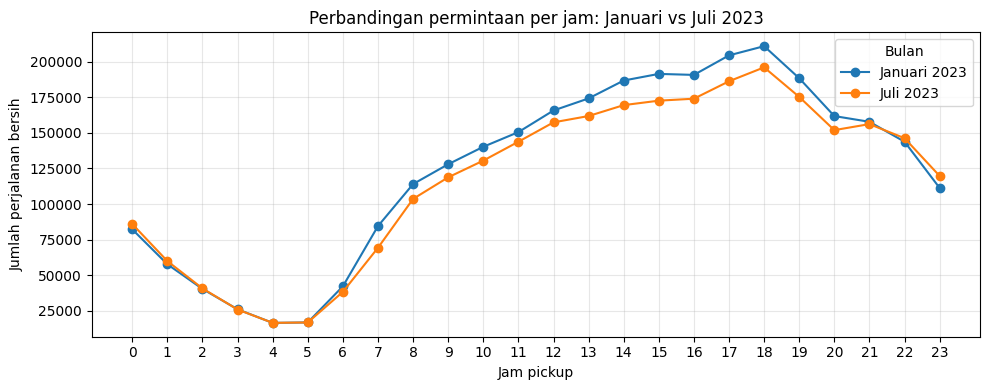

In [17]:
plot_bulan = perbandingan_bulan.set_index("jam")[["jumlah_januari", "jumlah_juli"]]
ax = plot_bulan.plot(figsize=(10, 4), marker="o")
ax.set_title("Perbandingan permintaan per jam: Januari vs Juli 2023")
ax.set_xlabel("Jam pickup")
ax.set_ylabel("Jumlah perjalanan bersih")
ax.set_xticks(range(24))
ax.legend(["Januari 2023", "Juli 2023"], title="Bulan")
ax.grid(alpha=0.3)
plt.tight_layout()
PATH_GRAFIK_BULAN = os.path.join(DIR_SIMPAN, "perbandingan_januari_juli.png")
plt.savefig(PATH_GRAFIK_BULAN, dpi=150, bbox_inches="tight")
plt.show()

## Tugas 3: laporan kinerja

`pengukuran_kinerja.csv` dilampirkan sebagai artefak pengukuran. Langkah termahal ditentukan berdasarkan durasi aktual pada runtime ini.

In [18]:
kinerja = pd.DataFrame(catatan).sort_values("detik", ascending=False).reset_index(drop=True)
kinerja.to_csv(PATH_KINERJA, index=False)
langkah_termahal = kinerja.iloc[0]
print("Urutan langkah berdasarkan durasi:")
display(kinerja)
print(
    f"Langkah termahal: {langkah_termahal['langkah']} "
    f"({langkah_termahal['detik']:.2f} detik; "
    f"delta RSS {langkah_termahal['delta_rss_mb']:+.1f} MB)."
)
print(
    "Perubahan konkret: untuk agregasi rutin, pertahankan data dalam Parquet "
    "dan baca hanya kolom yang diperlukan; hindari konversi ke CSV jika tidak "
    "dibutuhkan karena CSV lebih besar dan memerlukan parsing teks."
)

Urutan langkah berdasarkan durasi:


,langkah,detik,delta_rss_mb
0,tulis CSV Juli,42.82,5.6
1,Spark agregasi Juli,5.96,0.0
2,agregasi chunking Juli,5.03,29.3
3,baca semua kolom Juli,4.50,495.5
4,spark count Juli,2.86,0.0
5,baca kolom terpilih Juli,0.69,121.1


Langkah termahal: tulis CSV Juli (42.82 detik; delta RSS +5.6 MB).
Perubahan konkret: untuk agregasi rutin, pertahankan data dalam Parquet dan baca hanya kolom yang diperlukan; hindari konversi ke CSV jika tidak dibutuhkan karena CSV lebih besar dan memerlukan parsing teks.


## Tugas 4: refleksi teori 5V

Refleksi berikut menggunakan angka dari eksekusi Juli 2023 dan perbandingan Januari-Juli.

In [19]:
ukuran_parquet_juli = os.path.getsize(PATH_JUL) / 1024**2
ukuran_csv_juli = os.path.getsize(CSV_JULI) / 1024**2
baris_dibuang_juli = len(df_juli) - len(bersih_juli)
persen_dibuang_juli = 100 * baris_dibuang_juli / len(df_juli)
ringkas_5v = pd.DataFrame([
    {
        "dimensi": "Volume",
        "bukti_angka": f"{len(df_juli):,} baris Juli; file {ukuran_parquet_juli:.1f} MB",
        "interpretasi": "Paling menonjol: jutaan baris membutuhkan projection, dtype optimization, chunking, dan Spark lokal."
    },
    {
        "dimensi": "Velocity",
        "bukti_angka": "Dataset berupa snapshot bulanan, bukan aliran data real-time",
        "interpretasi": "Tidak benar-benar big pada velocity dalam praktikum ini; aspek ini baru dibahas secara konseptual."
    },
    {
        "dimensi": "Variety",
        "bukti_angka": f"Parquet {ukuran_parquet_juli:.1f} MB vs CSV bersih {ukuran_csv_juli:.1f} MB",
        "interpretasi": "Variety format terlihat dari perbedaan penyimpanan baris dan kolom, tetapi datanya tetap terstruktur."
    },
    {
        "dimensi": "Veracity",
        "bukti_angka": f"{baris_dibuang_juli:,} baris dibuang ({persen_dibuang_juli:.2f}%)",
        "interpretasi": "Kualitas data perlu diperiksa karena terdapat jarak, durasi, dan total_amount yang tidak layak."
    },
    {
        "dimensi": "Value",
        "bukti_angka": f"Puncak Juli jam {int(puncak_jul['jam']):02d}.00 dengan {int(puncak_jul['jumlah_juli']):,} perjalanan",
        "interpretasi": "Agregasi per jam menghasilkan informasi operasional untuk penjadwalan armada."
    }
])
display(ringkas_5v)
print(f"Volume: {len(df_juli):,} baris Juli dan {ukuran_parquet_juli:.1f} MB terkompresi menunjukkan bahwa ukuran data adalah dimensi paling nyata. "
      f"Namun, Velocity belum menjadi masalah karena data hadir sebagai file bulanan, bukan stream real-time. "
      f"Variety terbatas pada data terstruktur, tetapi pilihan Parquet {ukuran_parquet_juli:.1f} MB versus CSV {ukuran_csv_juli:.1f} MB menunjukkan perbedaan format yang penting untuk analitik. "
      f"Veracity terlihat dari pembuangan {baris_dibuang_juli:,} baris atau {persen_dibuang_juli:.2f}% akibat nilai yang tidak layak. "
      f"Value muncul dari pola permintaan per jam; Juli mencapai puncak pada jam {int(puncak_jul['jam']):02d}.00 dengan {int(puncak_jul['jumlah_juli']):,} perjalanan bersih, sehingga hasil pengolahan dapat dipakai untuk menyusun shift armada.")

,dimensi,bukti_angka,interpretasi
0,Volume,"2,907,108 baris Juli; file 46.1 MB",Paling menonjol: jutaan baris membutuhkan proj...
1,Velocity,"Dataset berupa snapshot bulanan, bukan aliran ...",Tidak benar-benar big pada velocity dalam prak...
2,Variety,Parquet 46.1 MB vs CSV bersih 213.6 MB,Variety format terlihat dari perbedaan penyimp...
3,Veracity,"89,451 baris dibuang (3.08%)",Kualitas data perlu diperiksa karena terdapat ...
4,Value,"Puncak Juli jam 18.00 dengan 195,988 perjalanan",Agregasi per jam menghasilkan informasi operas...


Volume: 2,907,108 baris Juli dan 46.1 MB terkompresi menunjukkan bahwa ukuran data adalah dimensi paling nyata. Namun, Velocity belum menjadi masalah karena data hadir sebagai file bulanan, bukan stream real-time. Variety terbatas pada data terstruktur, tetapi pilihan Parquet 46.1 MB versus CSV 213.6 MB menunjukkan perbedaan format yang penting untuk analitik. Veracity terlihat dari pembuangan 89,451 baris atau 3.08% akibat nilai yang tidak layak. Value muncul dari pola permintaan per jam; Juli mencapai puncak pada jam 18.00 dengan 195,988 perjalanan bersih, sehingga hasil pengolahan dapat dipakai untuk menyusun shift armada.
